<h3><center> Assignment </center></h3>

Implement and test the upper barrier put option pricers under continuous monitoring. (15p = 7p+4p+4p)

a.) Implement the barrier up-and-in put option (UIP) and up-and-out put option (UOP) pricers in the codebase.

b.) Where do the prices of UIP/UOP options converge, if the barrier tends to infinity? Create a graph to visualize the results.

c.) Create a unit test that asserts the in-out parity for UIP and UOP barrier options. Put it inside the 'TestBarrierPricer' class of the 'test_pricer.py' file.

## a, Implement the barrier up-and-in put option (UIP) and up-and-out put option (UOP) pricers in the codebase.

From the in-out parity we know: $\quad P_{UIP}+P_{UOP} = P_{European\ Call}$


<h3><center> Pricing for $t=0$ under GBM and continuous monitoring </center></h3>

- Black-Scholes formula: $BS_{put}(S_0, K, T, \sigma, r) = 
-S_0 \Phi\left( -\delta_+^T \left( \frac{S_0}{K} \right) \right) + K e^{-rT} \Phi\left( -\delta_-^T \left( \frac{S_0}{K} \right) \right)$
- Using the B-S formula, the UIP price becomes (if $B\geq K$): 
$\quad S_0\left( \frac{B}{S_0}\right)^{\frac{2r}{\sigma^2}} BS_{put}\left( \frac{B}{S_0}, \frac{K}{B}, T, \sigma, r \right) $
- UOP price if $B\geq K$: 
$\qquad BS_{put}(S_0, K, T, \sigma, r) - S_0\left( \frac{B}{S_0}\right)^{\frac{2r}{\sigma^2}} BS_{put}\left( \frac{B}{S_0}, \frac{K}{B}, T, \sigma, r \right) $

Since we have the in-outt parity, I implemented the pricing formula for UIP and used the parity to calculate UOP just like in the previous code for DIC and DOC

## b, Where do the prices of UIP/UOP options converge, if the barrier tends to infinity? Create a graph to visualize the results.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

current = Path().resolve()
sys.path.append(str(current))
sys.path.append(str(current.parents[2]))

from src.enums import *
from src.utils import *
from src.market_data import *
from src.pricer import *
# # Make charts interactive
# %matplotlib notebook

# Initialize market data
MarketData.initialize()

QuantCourseBP 439d6a142f71633bcedd46f2e2a0e8d449967753*


First, with the help of the MC method, we can simulate price paths and check what happens. I simulated 20 paths and plotted 5 different barrier levels.

In [5]:
und = Stock.TEST_COMPANY
model = BSVolModel(und)

strike = 100
expiry = 1
long_short = LongShort.LONG
dtype = PutCallFwd.PUT
up_down = UpDown.UP
in_out = InOut.IN

num_mon = 1000
barrier_list = [105, 115, 130, 150, 180]
num_of_paths = 20    

params_MC_mod = MCParams(seed = 11, num_of_path = num_of_paths, tenor_frequency = 1000)

In [6]:
contract_mod = EuropeanBarrierContract(
    und, dtype, long_short, strike, expiry,
    num_mon, barrier_list[0], up_down, in_out
)

method = MCMethodFlatVol(contract_mod, model, params_MC_mod)
paths = method.simulate_spot_paths()

timeline = [0] + contract_mod.get_timeline()

We can see on the plot, that as the barrier gets higher, less paths will breach it. So if we have a knock-in option, its value will go to zero, because none of the paths will "make it active". In case of a knock-out option, if the barrier level gets higher, the value of the option will approximate the vanilla put option, because the barrier will never be breached basically.

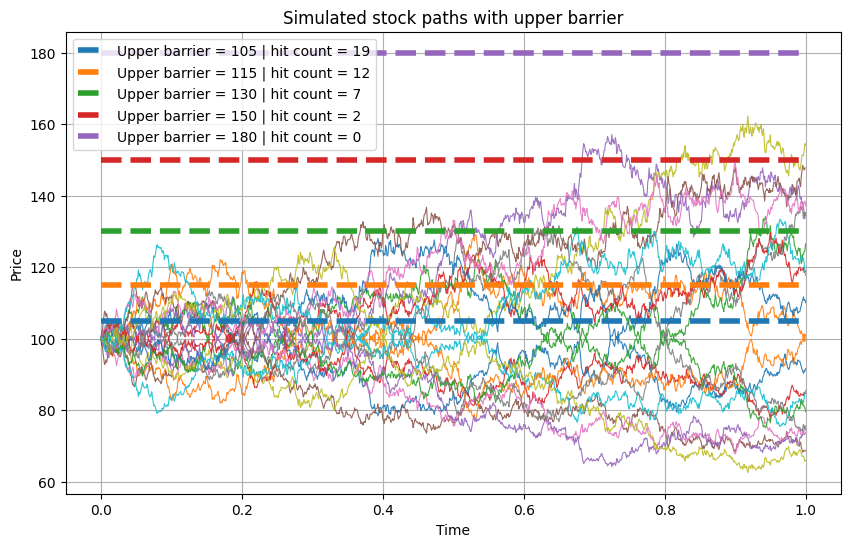

In [7]:
plt.figure(figsize=(10, 6))

for i in range(num_of_paths):
    path = np.concatenate((np.array([model.spot]), paths[i, :]))
    plt.plot(timeline, path, linewidth=0.8, alpha=0.9)

for barrier in barrier_list:
    hit_count = 0

    for i in range(num_of_paths):
        path = np.concatenate((np.array([model.spot]), paths[i, :]))
        if max(path) >= barrier:
            hit_count += 1

    barrier_timeline = [barrier for _ in timeline]
    plt.plot(
        timeline,
        barrier_timeline,
        '--',
        linewidth=4,
        label=f"Upper barrier = {barrier} | hit count = {hit_count}"
    )

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Simulated stock paths with upper barrier")
plt.legend()
plt.grid()
plt.show()

No we can plot the values of OUP and OIP options as the barrier gets higher and we can see the results matching our expectations.

In [8]:
und = Stock.TEST_COMPANY
model = BSVolModel(und)
spot = model.spot

strike = 100
num_mon = 1   #now its countinous, doesnt matter
up_down = UpDown.UP
dtype = PutCallFwd.PUT
long_short = LongShort.LONG
expiry = 1
params = Params()

#barrier values
list_barrier = np.linspace(105, 200, 100)

list_price_UIP = []
list_price_UOP = []
list_price_PUT = []

#calculating put price
contract_put = EuropeanContract(und, dtype, long_short, strike, expiry)
pricer_put = EuropeanAnalyticPricer(contract_put, model, params)
price_put = pricer_put.calc_fair_value()

for barrier in list_barrier:

    contract_UIP = EuropeanBarrierContract(
        und, dtype, long_short, strike, expiry,
        num_mon, barrier, up_down, InOut.IN
    )

    contract_UOP = EuropeanBarrierContract(
        und, dtype, long_short, strike, expiry,
        num_mon, barrier, up_down, InOut.OUT
    )

    pricer_UIP = BarrierAnalyticPricer(contract_UIP, model, params)
    pricer_UOP = BarrierAnalyticPricer(contract_UOP, model, params)

    list_price_UIP.append(pricer_UIP.calc_fair_value())
    list_price_UOP.append(pricer_UOP.calc_fair_value())
    list_price_PUT.append(price_put)

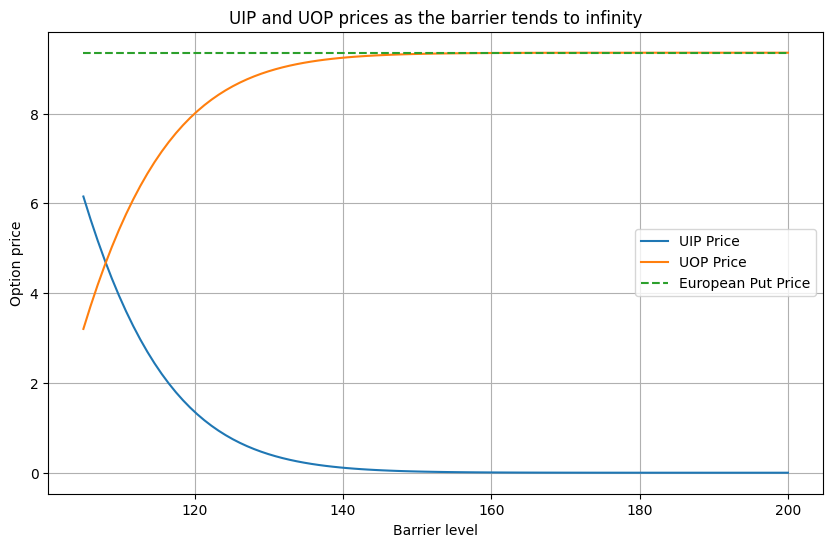

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(list_barrier, list_price_UIP, label="UIP Price")
plt.plot(list_barrier, list_price_UOP, label="UOP Price")
plt.plot(list_barrier, list_price_PUT, "--", label="European Put Price")

plt.xlabel("Barrier level")
plt.ylabel("Option price")
plt.title("UIP and UOP prices as the barrier tends to infinity")
plt.legend()
plt.grid()
plt.show()